# Name:Jakiel
# Date: 11-20-25 
## Using Medical Costs Dataset (Predict insurance charges based on age, BMI, smoking status)



# Section 1. Import and Inspect the Data



In [194]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split


In [195]:
# 1.1 Load the dataset and display the first 10 rows.
insco = pd.read_csv('insurance.csv')
insco.head(10)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [196]:
# 1.2 Check for missing values and display summary statistics.
print(insco.isna().sum())

print(insco.info())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


Reflection 1: What do you notice about the dataset? Are there any data issues?

The dataset is a mix of numerical and categorical features. Since our target feature is charges is already numeric no need to convert but there are some like region, smoker and sex since they are objects.



# Section 2. Data Exploration and Preparation



In [197]:
#convert categorical features to numeric
insco['smoker'] = insco['smoker'].map({'yes': 1, 'no': 0})
insco['sex'] = insco['sex'].map({'male':1,'female':0})

print(insco.head())

   age  sex     bmi  children  smoker     region      charges
0   19    0  27.900         0       1  southwest  16884.92400
1   18    1  33.770         1       0  southeast   1725.55230
2   28    1  33.000         3       0  southeast   4449.46200
3   33    1  22.705         0       0  northwest  21984.47061
4   32    1  28.880         0       0  northwest   3866.85520


In [198]:
#display correlation  for feature selection
insco.corr(numeric_only=True)

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000


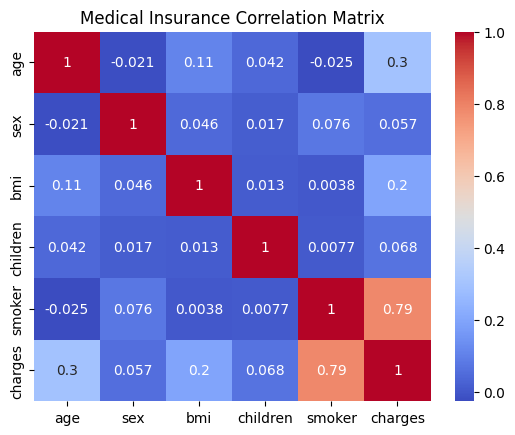

charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
Name: charges, dtype: float64

In [199]:
# plot correlation matrix 
sns.heatmap(insco.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Medical Insurance Correlation Matrix")
plt.show()

insco.corr(numeric_only=True)['charges'].sort_values(ascending=False)


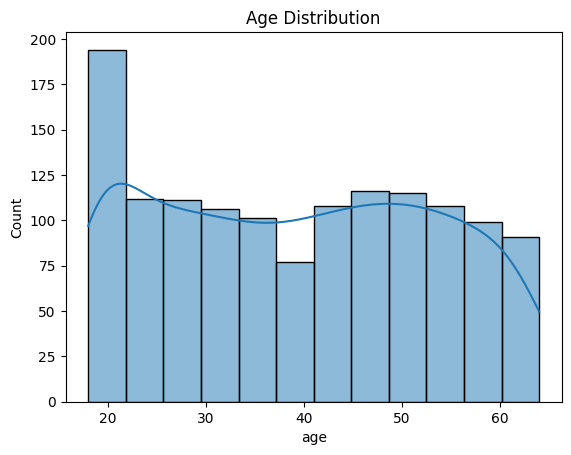

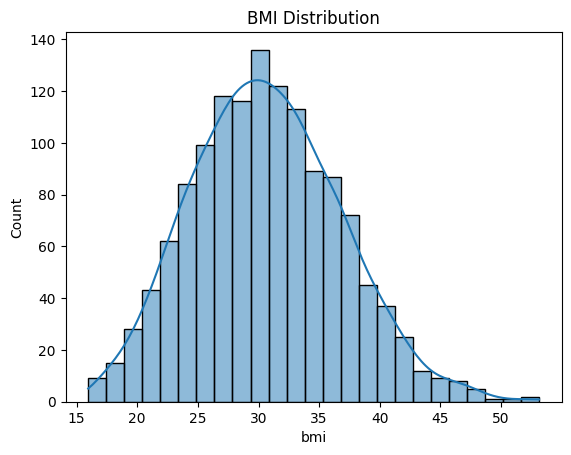

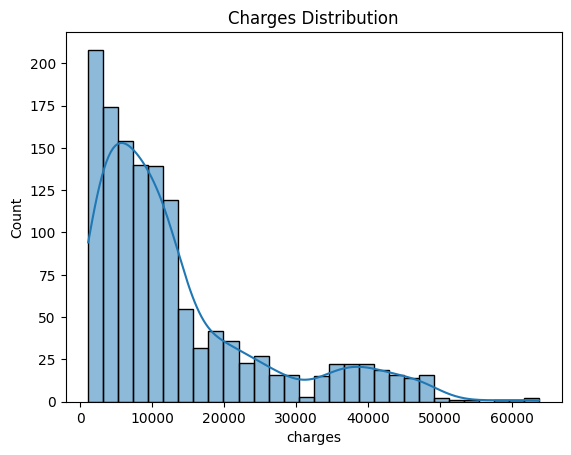

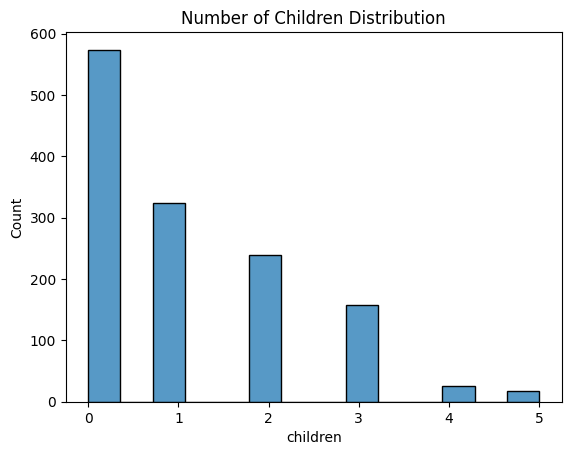

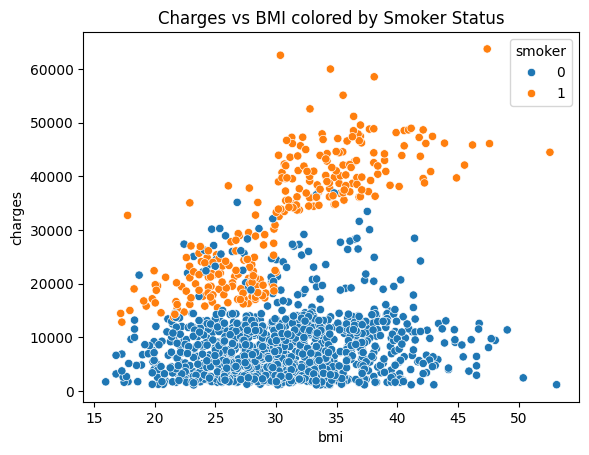

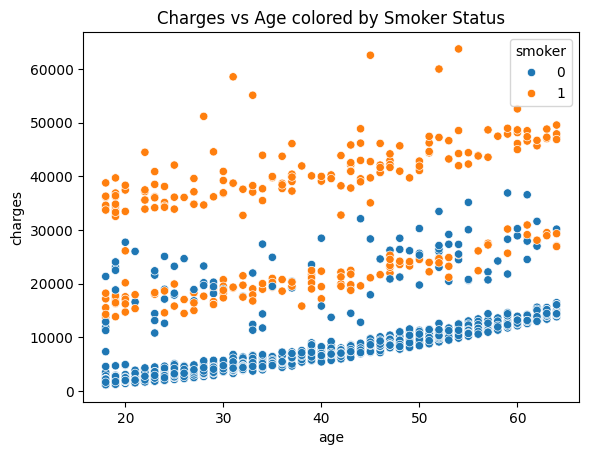

In [200]:
#Visualizations

sns.histplot(insco["age"], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(insco["bmi"], kde=True)
plt.title("BMI Distribution")
plt.show()  

sns.histplot(insco["charges"], kde=True)
plt.title("Charges Distribution")
plt.show()  

sns.histplot(insco["children"], kde=False   )
plt.title("Number of Children Distribution")
plt.show()

sns.scatterplot(x='bmi', y='charges', data=insco, hue='smoker')
plt.title("Charges vs BMI colored by Smoker Status")
plt.show()

sns.scatterplot(x='age', y='charges', data=insco, hue='smoker')
plt.title("Charges vs Age colored by Smoker Status")
plt.show()




Reflection 2: What patterns or anomalies do you see? Do any features stand out? What preprocessing steps were necessary to clean and improve the data? Did you create or modify any features to improve performance?

No missing values or messy data. Smoker, sex and region are the categorical features therefore I converted them to numerical but only kept smoker and sex to numeric and region.I didnt inlude region in the correlation matrix was insignificant.



# Section 3. Feature Selection and Justification



3.1 Choose features and target

I will use the features smoker ,bmi,age, children to predict the price the insurnace company charges the person.

In [201]:
#3.2 Define X and y
X = insco[['smoker', 'bmi', 'age', 'children']]
Y = insco['charges']

Reflection 3: Why did you choose these features? How might they impact predictions or accuracy?

Smoker had the stringest corrleation followed by age and bmi. I created a few vissaulteuons to shwo the pattern and how smoking status, age and bmi drastically incerases the  price the insurnace company charges.

# Section 4. Train a Model (Linear Regression)



In [202]:
#4.1 Split the data into training and test sets using train_test_split (or StratifiedShuffleSplit if class imbalance is an issue).
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=123)
print("Train size", len(X_train))
print("Test size", len(X_test))

Train size 1070
Test size 268


In [203]:
#4.2 Train model using Scikit-Learn model.fit() method
lr_model = LinearRegression().fit(X_train, Y_train)

#Predict on test and train sets
Y_pred_train = lr_model.predict(X_train)
Y_pred_test = lr_model.predict(X_test)


In [204]:
#4.3 Evalulate performance R2,MAE,RMSE
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
print("Training R2:",r2_score(Y_train,Y_pred_train))
print("R2:", r2_score(Y_test, Y_pred_test))
print("RMSE:", rmse)
print("MAE:", mean_absolute_error(Y_test, Y_pred_test))


Training R2: 0.7363720991582904
R2: 0.799036524815733
RMSE: 5543.141792764445
MAE: 4074.8228873944904


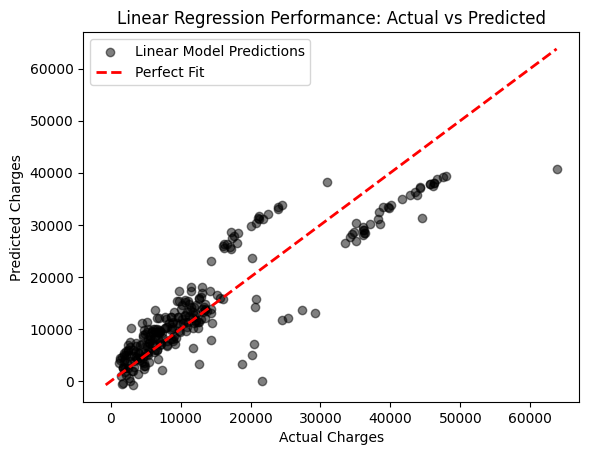

In [205]:
#Actual vs Predicted Charges for linear regression model
plt.scatter(Y_test, Y_pred_test, color='black', alpha=0.5, label='Linear Model Predictions')


min_val = min(Y_test.min(), Y_pred_test.min())
max_val = max(Y_test.max(), Y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Linear Regression Performance: Actual vs Predicted")
plt.legend()
plt.show()

Reflection 4: How well did the model perform? Any surprises in the results?

RMSE ($5,543) is significantly higher than the MAE ($4,074). This gap, combined with the 'curve' visible in the Actual vs. Predicted plot, 

The model performed well with smoker feature doing the heavy lifting.  The r2 is .79, rmse  of $5543 and mae of $4074. This means the model was wrong by $4074 and the $1500 difference indicates the model is struggling with outliers likely the high cost smokers because.The scatter pot helps shw this. You can see as the charges go past $20,000 there are less points near the red line. 

# Section 5. Improve the Model or Try Alternates (Implement Pipelines)



In [206]:
#Polynomial Regression
polyreg = PolynomialFeatures(degree=2)
X_test_poly = polyreg.fit_transform(X_test)
X_train_poly = polyreg.fit_transform(X_train)

poly_model = LinearRegression()
poly_model.fit(X_train_poly,Y_train)
Y_pred_test_poly = poly_model.predict(X_test_poly)

poly_r2 = r2_score(Y_test, Y_pred_test_poly)
poly_mae = mean_absolute_error(Y_test, Y_pred_test_poly)
poly_mse = mean_squared_error(Y_test, Y_pred_test_poly)
poly_rmse = np.sqrt(poly_mse)

print("Polynomial Regression Performance:")
print("Training R2:",r2_score(Y_train,Y_pred_train))
print("R2:", poly_r2)
print("RMSE:", poly_rmse)
print("MAE:", poly_mae)

Polynomial Regression Performance:
Training R2: 0.7363720991582904
R2: 0.9047923143910475
RMSE: 3815.341582630957
MAE: 2547.7364814486104


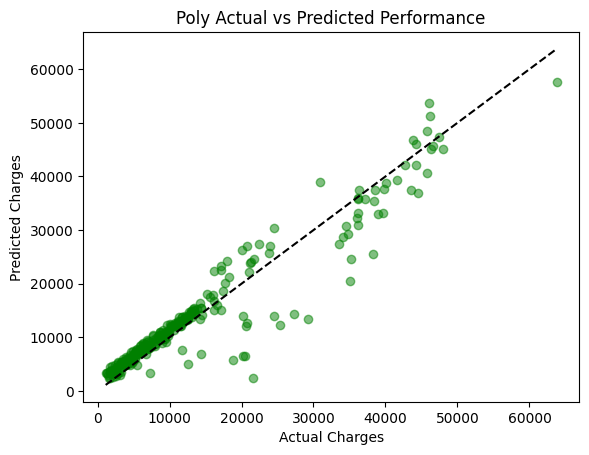

In [207]:
#visualize polynomial regression
plt.scatter(Y_test, Y_pred_test_poly, color='green', alpha=0.5)

# Plot a fit line 
min_val = min(Y_test.min(), Y_pred_test_poly.min())
max_val = max(Y_test.max(), Y_pred_test_poly.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Poly Actual vs Predicted Performance")
plt.show()


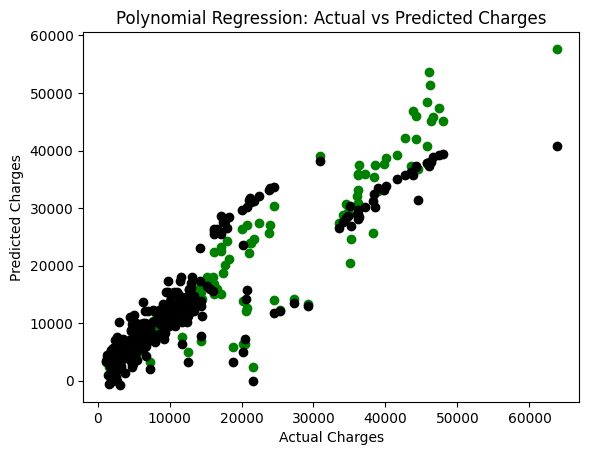

In [208]:
#actual
plt.scatter(Y_test, Y_pred_test_poly, color='green')
plt.xlabel("Actual Charges")

#predicted
plt.scatter(Y_test, Y_pred_test, color='black')
plt.ylabel("Predicted Charges")

plt.title("Polynomial Regression: Actual vs Predicted Charges")
plt.show()

Reflection 5: Which models performed better? How does scaling impact results?

The Polynomial Regression performed significantly better. It increased the r2
to 0.905 and dropped the RMSE to $3,815. The scatter plots show the poly predictions fitting the perfect line of the data much tighter than the linear mode.
The polynomial model performed much better with a r2 score of .9048.This model reduced mae by $1527, to $2547.The model comparison plot easily shows that the poly model had more instances along the perfect line compared to the linear regression model. As the charges get higher the polynomial predicted the charge more accuaretley. In the most simple of ways the green dots are closer to the perfct line as compared to the black dots as the insurance charge goes above $20,000.

# Section 6. Final Thoughts & Insights

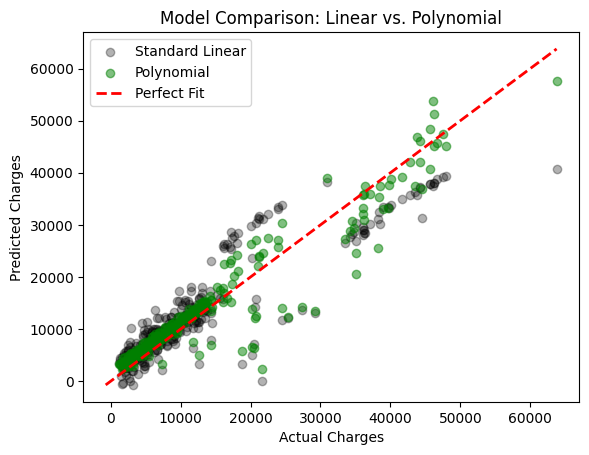

In [209]:
#Linear Regression Model
plt.scatter(Y_test, Y_pred_test, color='black', alpha=0.3, label='Standard Linear')

#Polynomial Model
plt.scatter(Y_test, Y_pred_test_poly, color='green', alpha=0.5, label='Polynomial')

min_val = min(Y_test.min(), Y_pred_test.min())
max_val = max(Y_test.max(), Y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

# Labels
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Model Comparison: Linear vs. Polynomial")
plt.legend() 
plt.show()

In [210]:

lr_r2 = r2_score(Y_test, Y_pred_test)
lr_mae = mean_absolute_error(Y_test, Y_pred_test)
lr_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))

poly_r2 = r2_score(Y_test, Y_pred_test_poly)
poly_mae = mean_absolute_error(Y_test, Y_pred_test_poly)
poly_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test_poly))

print(f"{'Metric':<10} | {'Linear Model':<15} | {'Polynomial Model':<15}")
print("-" * 46)
print(f"{'R2':<10} | {lr_r2:<15.4f} | {poly_r2:<15.4f}")
print(f"{'MAE':<10} | ${lr_mae:<14.2f} | ${poly_mae:<14.2f}")
print(f"{'RMSE':<10} | ${lr_rmse:<14.2f} | ${poly_rmse:<14.2f}")

Metric     | Linear Model    | Polynomial Model
----------------------------------------------
R2         | 0.7990          | 0.9048         
MAE        | $4074.82        | $2547.74       
RMSE       | $5543.14        | $3815.34       


Reflection 6: What did you learn from this project?

Visualizations were what made understanding the data easier for me. As a data analyst, they are important for helping stakeholders, or anyone who isn't technical, to understand the metrics. The plots really helped put the errors into perspective. The polynomial model reduced the MAE by around $1,500, which is significant when it comes to a family or person trying to gauge their payments. This is useful in the real world as customers shop for prices and estimate what they may have to pay. Sometimes it’s not good enough to know if a model is right or wrong, but how wrong it is. 
